# Importing the libraries

In [1]:
import pandas as pd
from datetime import datetime, timezone
import pytz
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Process the activity data by first reading it, ensuring its cleanliness, and then resampling it as needed.

In [2]:
import pandas as pd

df = pd.read_csv("HUPA0018P.csv", sep=";")

df["time"] = pd.to_datetime(df["time"])
df.set_index("time", inplace=True)

df_steps_hr = df[["heart_rate", "steps"]]

# Rename index
df_steps_hr.index.name = "Timestamp"

df_steps_hr

,heart_rate,steps
Timestamp,,
2019-07-03 11:15:00,64.455285,0.0
2019-07-03 11:20:00,65.051095,0.0
2019-07-03 11:25:00,66.856000,0.0
2019-07-03 11:30:00,67.155039,9.0
2019-07-03 11:35:00,65.792593,19.0
...,...,...
2019-07-16 23:25:00,85.634328,0.0
2019-07-16 23:30:00,85.459259,0.0
2019-07-16 23:35:00,84.325581,0.0


In [3]:
data_activity = df_steps_hr.copy()
data_activity['Activity'] = data_activity['steps'] * data_activity['heart_rate']
data_activity = data_activity.groupby(data_activity.index).mean()
data_activity = data_activity[(data_activity.index.hour >= 6) & (data_activity.index.hour <= 23)]
data_activity.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2959 entries, 2019-07-03 11:15:00 to 2019-07-16 23:45:00
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   heart_rate  2959 non-null   float64
 1   steps       2959 non-null   float64
 2   Activity    2959 non-null   float64
dtypes: float64(3)
memory usage: 92.5 KB


In [4]:
data_activity.describe()

,heart_rate,steps,Activity
count,2959.000000,2959.000000,2959.000000
mean,81.105599,44.879351,4149.175303
std,13.886933,77.330599,7486.982607
min,53.393443,0.000000,0.000000
25%,71.336325,0.000000,0.000000
50%,81.964286,0.000000,0.000000
75%,91.276007,62.000000,5378.950413
max,140.194631,486.000000,51547.881356


In [5]:
mean_activity = data_activity['Activity'].mean()
std_activity = data_activity['Activity'].std()
fig = go.Figure()
fig.add_trace(go.Scatter(x=data_activity.index, y=data_activity['Activity'], mode='lines + markers', name='Activity'))
fig.add_trace(go.Scatter(
    x=data_activity.index, 
    y=[mean_activity] * len(data_activity), 
    mode='lines', 
    name='Mean Activity',
    line=dict(dash='dash', color='green')
))
fig.add_trace(go.Scatter(
    x=data_activity.index, 
    y=[std_activity] * len(data_activity), 
    mode='lines', 
    name='Mean + Std',
    line=dict(dash='dot', color='red')
))
fig.update_layout(
    title="Activity Over Time",
    xaxis_title="Timestamp",
    yaxis_title="Activity Level",
)
fig.show()

In [6]:
mean_activity = data_activity.Activity.mean()
filtered_data_activity = data_activity[data_activity['Activity'] > mean_activity]
x0 = filtered_data_activity.Activity.min()
x1 = filtered_data_activity.Activity.quantile(0.25)
x2 = filtered_data_activity.Activity.quantile(0.5)
x3 = filtered_data_activity.Activity.quantile(0.75)
x4 = filtered_data_activity.Activity.max()
filtered_data_activity.describe()

,heart_rate,steps,Activity
count,854.000000,854.000000,854.000000
mean,91.584932,139.811475,13054.254653
std,9.977119,87.633406,8949.834625
min,64.216216,39.000000,4150.625000
25%,84.553629,75.250000,6488.976855
50%,91.539237,110.000000,10059.301524
75%,98.580916,179.000000,16483.673062
max,140.194631,486.000000,51547.881356


In [7]:
filtered_data_lows = filtered_data_activity[(filtered_data_activity['Activity'] >= x0) & (filtered_data_activity['Activity'] < x1)]
filtered_data_mediums = filtered_data_activity[(filtered_data_activity['Activity'] >= x1) & (filtered_data_activity['Activity'] < x2)]
filtered_data_highs = filtered_data_activity[(filtered_data_activity['Activity'] >= x2) & (filtered_data_activity['Activity'] < x3)]
filtered_data_very_highs = filtered_data_activity[(filtered_data_activity['Activity'] >= x3) & (filtered_data_activity['Activity'] <= x4)]
filtered_data_lows

,heart_rate,steps,Activity
Timestamp,,,
2019-07-03 12:10:00,64.216216,66.0,4238.270270
2019-07-03 12:30:00,64.767857,87.0,5634.803571
2019-07-03 13:05:00,74.869919,75.0,5615.243902
2019-07-03 14:05:00,92.515152,45.0,4163.181818
2019-07-03 14:10:00,103.440299,55.0,5689.216418
...,...,...,...
2019-07-16 18:55:00,96.671756,62.0,5993.648855
2019-07-16 19:05:00,97.055556,49.0,4755.722222
2019-07-16 21:15:00,84.967742,75.0,6372.580645


# Process the glucose data by first reading it, ensuring its cleanliness, and then resampling it as needed

In [8]:
import pandas as pd

df = pd.read_csv("HUPA0018P.csv", sep=";")

# Convert time
df["time"] = pd.to_datetime(df["time"], errors="coerce")

# Select + rename columns
df_glucose = df[["time", "glucose"]].copy()
df_glucose.rename(columns={"time": "Timestamp", "glucose": "Glucose"}, inplace=True)

# Clean
df_glucose["Glucose"] = pd.to_numeric(df_glucose["Glucose"], errors="coerce")
df_glucose.dropna(inplace=True)

# Set index
df_glucose.set_index("Timestamp", inplace=True)
df_glucose["Glucose"] = df_glucose["Glucose"] / 18.0182
data_glucose = df_glucose.copy()
data_glucose.tail(20)

,Glucose
Timestamp,
2019-07-16 22:10:00,2.626973
2019-07-16 22:15:00,2.830471
2019-07-16 22:20:00,3.662963
2019-07-16 22:25:00,4.495455
2019-07-16 22:30:00,5.327946
2019-07-16 22:35:00,5.549944
2019-07-16 22:40:00,5.771942
2019-07-16 22:45:00,5.993939
2019-07-16 22:50:00,6.567434


In [9]:
data_glucose = data_glucose[data_glucose.index.minute % 15 == 0].copy()

data_glucose.loc[:, 'nextGlucose'] = data_glucose['Glucose'].shift(-1)
data_glucose.loc[:, 'GlucoseChange'] = data_glucose['Glucose'] - data_glucose['nextGlucose']

data_glucose = data_glucose[:-1]

data_glucose = data_glucose.reset_index()

data_glucose = data_glucose[
    (data_glucose['Timestamp'].shift(-1) - data_glucose['Timestamp'])
    .dt.total_seconds() / 60 == 15
]

data_glucose = data_glucose.set_index('Timestamp')

data_glucose = data_glucose.dropna()
data_glucose

,Glucose,nextGlucose,GlucoseChange
Timestamp,,,
2019-07-03 11:15:00,5.993939,5.549944,0.443996
2019-07-03 11:30:00,5.549944,5.161448,0.388496
2019-07-03 11:45:00,5.161448,4.495455,0.665993
2019-07-03 12:00:00,4.495455,3.773962,0.721493
2019-07-03 12:15:00,3.773962,6.382436,-2.608474
...,...,...,...
2019-07-16 22:15:00,2.830471,5.327946,-2.497475
2019-07-16 22:30:00,5.327946,5.993939,-0.665993
2019-07-16 22:45:00,5.993939,7.714422,-1.720483


# Merge Glucose with Different Levels of Activity

In [10]:
def process_glucose_changes(filtered_data, data_glucose):
    merged_data = pd.merge(filtered_data, data_glucose, left_index=True, right_index=True, how='inner')
    merged_data = merged_data[merged_data['Glucose'] > merged_data['nextGlucose']]
    merged_data.reset_index(inplace=True)
    return merged_data
actgluco_low = process_glucose_changes(filtered_data_lows, data_glucose)
actgluco_medium = process_glucose_changes(filtered_data_mediums, data_glucose)
actgluco_high = process_glucose_changes(filtered_data_highs, data_glucose)
actgluco_very_high = process_glucose_changes(filtered_data_very_highs, data_glucose)

for name, df in zip(
    ['low', 'medium', 'high', 'very_high'],
    [actgluco_low, actgluco_medium, actgluco_high, actgluco_very_high]
):
    df.to_csv(f'actgluco_{name}.csv', index=False)

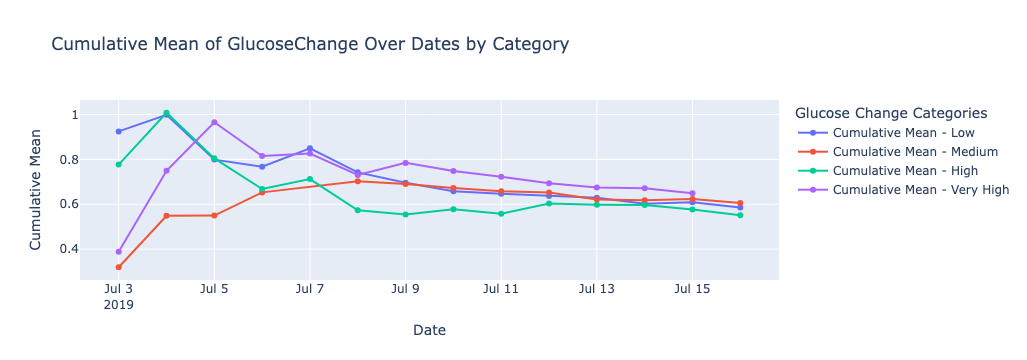

In [11]:
def plot_multiple_cumulative_means(data_dict):
    fig = go.Figure()
    
    for label, data in data_dict.items():
        unique_dates = sorted(data['Timestamp'].dt.date.unique())
        cumulative_means = []
        
        for i in range(len(unique_dates)):
            current_data = data[data['Timestamp'].dt.date <= unique_dates[i]]
            mean = current_data['GlucoseChange'].mean()
            cumulative_means.append(mean)
        
        fig.add_trace(go.Scatter(
            x=unique_dates,
            y=cumulative_means,
            mode='lines+markers',
            name=f'Cumulative Mean - {label}'
        ))
    
    fig.update_layout(
        title="Cumulative Mean of GlucoseChange Over Dates by Category",
        xaxis_title="Date",
        yaxis_title="Cumulative Mean",
        legend_title="Glucose Change Categories"
    )
    
    fig.show()
    
data_dict = {
    "Low": actgluco_low,
    "Medium": actgluco_medium,
    "High": actgluco_high,
    "Very High": actgluco_very_high
}

plot_multiple_cumulative_means(data_dict)

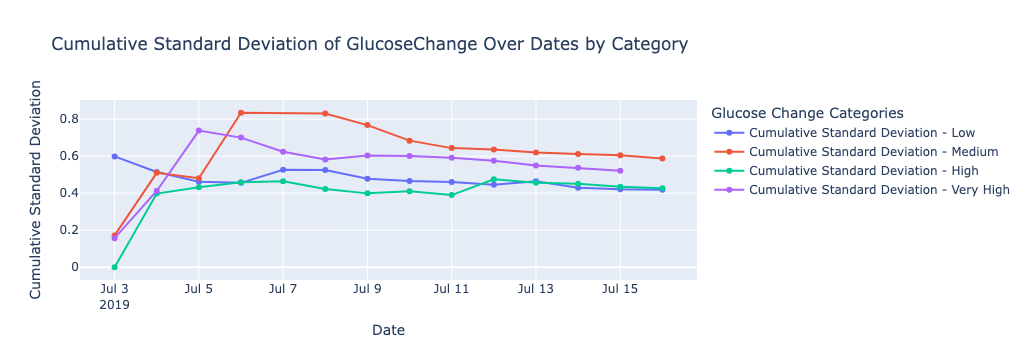

In [12]:
def plot_multiple_cumulative_std(data_dict):
    fig = go.Figure()
    
    for label, data in data_dict.items():
        unique_dates = sorted(data['Timestamp'].dt.date.unique())
        cumulative_std = []
        
        for i in range(len(unique_dates)):
            current_data = data[data['Timestamp'].dt.date <= unique_dates[i]]
            std = current_data['GlucoseChange'].std()
            cumulative_std.append(std)
        
        fig.add_trace(go.Scatter(
            x=unique_dates,
            y=cumulative_std,
            mode='lines+markers',
            name=f'Cumulative Standard Deviation - {label}'
        ))
    
    fig.update_layout(
        title="Cumulative Standard Deviation of GlucoseChange Over Dates by Category",
        xaxis_title="Date",
        yaxis_title="Cumulative Standard Deviation",
        legend_title="Glucose Change Categories"
    )
    
    fig.show()
data_dict = {
    "Low": actgluco_low,
    "Medium": actgluco_medium,
    "High": actgluco_high,
    "Very High": actgluco_very_high
}

plot_multiple_cumulative_std(data_dict)

# Moving Average Window

In [13]:
def mean_std_predict_next_day(filtered_data, category_name, window_size=10):
    filtered_data['Date'] = pd.to_datetime(filtered_data['Timestamp']).dt.date
    unique_days = sorted(filtered_data['Date'].unique())

    results = []

    for i in range(len(unique_days) - window_size):
        window_days = unique_days[i:i + window_size]            
        predict_day_index = i + window_size
        
        if predict_day_index >= len(unique_days):
            break
        
        predict_day = unique_days[predict_day_index]

        window_data = filtered_data[filtered_data['Date'].isin(window_days)]
        next_day_data = filtered_data[filtered_data['Date'] == predict_day]

        if next_day_data.empty:
            continue

        mean_glucose = window_data['GlucoseChange'].mean()
        std_glucose = window_data['GlucoseChange'].std()

        actual_mean_next = next_day_data['GlucoseChange'].mean()
        actual_std_next = next_day_data['GlucoseChange'].std()

        lower_bound = mean_glucose - std_glucose
        upper_bound = mean_glucose + std_glucose

        prediction_status = lower_bound <= actual_mean_next <= upper_bound

        results.append({
            'Category': category_name,
            'Window Start': window_days[0],
            'Window End': window_days[-1],
            'Predicted Mean': mean_glucose,
            'Predicted Standard Deviation': std_glucose,
            'Lower Bound': lower_bound,
            'Upper Bound': upper_bound,
            'Next Day': predict_day,
            'Actual Next Day Mean': actual_mean_next,
            'Actual Next Day Standard Deviation': actual_std_next,
            'Prediction Status': prediction_status
        })

    return pd.DataFrame(results)
window_size = 10

result_df_lows = mean_std_predict_next_day(actgluco_low, 'Lows', window_size)
result_df_mediums = mean_std_predict_next_day(actgluco_medium, 'Mediums', window_size)
result_df_highs = mean_std_predict_next_day(actgluco_high, 'Highs', window_size)
result_df_very_highs = mean_std_predict_next_day(actgluco_very_high, 'Very Highs', window_size)

all_results_df = pd.concat([result_df_lows, result_df_mediums, result_df_highs, result_df_very_highs])

category_order = ['Lows', 'Mediums', 'Highs', 'Very Highs']
all_results_df['Category'] = pd.Categorical(all_results_df['Category'], categories=category_order, ordered=True)

all_results_df.to_csv(f'rolling_window_glucose_prediction.csv', index=False)

grouped_results = all_results_df.groupby('Category', observed=True).agg({'Prediction Status': ['sum', 'count']})
print(grouped_results)

           Prediction Status      
                         sum count
Category                          
Lows                       4     4
Mediums                    3     3
Highs                      4     4
Very Highs                 3     3


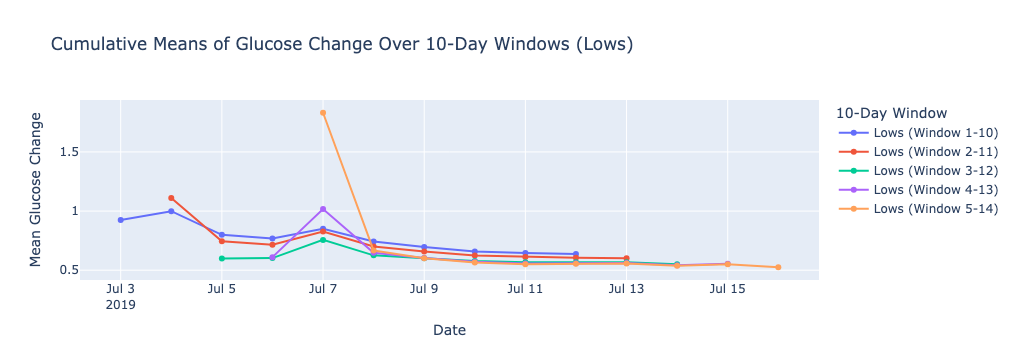

In [14]:
def plot_means_by_inner_window(filtered_data, label):
    filtered_data['Date'] = pd.to_datetime(filtered_data['Timestamp']).dt.date
    unique_days = sorted(filtered_data['Date'].unique())
    
    fig = go.Figure()

    for start_day in range(len(unique_days) - 9):
        dates = []
        means = []
        current_window = unique_days[start_day:start_day + 10]
        cumulative_filtered_data = filtered_data[filtered_data['Date'] >= unique_days[start_day]]
        
        for current_date in current_window:
            cumulative_data = cumulative_filtered_data[cumulative_filtered_data['Date'] <= current_date]['GlucoseChange']
            means.append(cumulative_data.mean() if len(cumulative_data) > 0 else 0)
            dates.append(current_date)
        
        fig.add_trace(go.Scatter(
            x=dates,
            y=means,
            mode='lines+markers',
            name=f"{label} (Window {start_day+1}-{start_day+10})"
        ))

    fig.update_layout(
        title=f'Cumulative Means of Glucose Change Over 10-Day Windows ({label})',
        xaxis_title='Date',
        yaxis_title='Mean Glucose Change',
        legend_title='10-Day Window',
        hovermode='x unified'
    )

    fig.show()

plot_means_by_inner_window(actgluco_low, label='Lows')

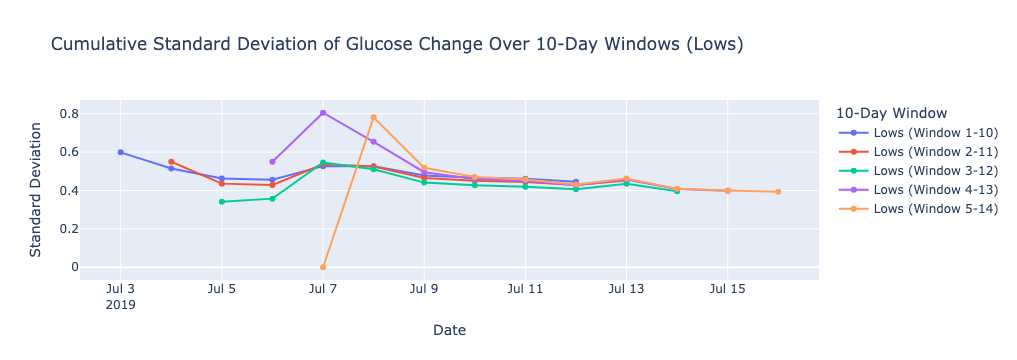

In [15]:
def plot_std_by_inner_window(filtered_data, label):
    filtered_data['Date'] = pd.to_datetime(filtered_data['Timestamp']).dt.date
    unique_days = sorted(filtered_data['Date'].unique())
    
    fig = go.Figure()

    for start_day in range(len(unique_days) - 9):
        dates = []
        std = []
        current_window = unique_days[start_day:start_day + 10]
        cumulative_filtered_data = filtered_data[filtered_data['Date'] >= unique_days[start_day]]
        
        for current_date in current_window:
            cumulative_data = cumulative_filtered_data[cumulative_filtered_data['Date'] <= current_date]['GlucoseChange']
            std.append(cumulative_data.std() if len(cumulative_data) > 1 else 0)
            dates.append(current_date)
        
        fig.add_trace(go.Scatter(
            x=dates,
            y=std,
            mode='lines+markers',
            name=f"{label} (Window {start_day+1}-{start_day+10})"
        ))

    fig.update_layout(
        title=f'Cumulative Standard Deviation of Glucose Change Over 10-Day Windows ({label})',
        xaxis_title='Date',
        yaxis_title='Standard Deviation',
        legend_title='10-Day Window',
        hovermode='x unified'
    )

    fig.show()

plot_std_by_inner_window(actgluco_low, label='Lows')